In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sklearn.datasets
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [135]:
data = sklearn.datasets.fetch_california_housing()

In [136]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [137]:
df = pd.DataFrame(data.data, columns = data.feature_names)

In [138]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [139]:
df['Price'] = data.target

In [140]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [141]:
df.shape

(20640, 9)

In [142]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [144]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [145]:
df.duplicated().sum()

np.int64(0)

In [146]:
df.nunique()

MedInc        12928
HouseAge         52
AveRooms      19392
AveBedrms     14233
Population     3888
AveOccup      18841
Latitude        862
Longitude       844
Price          3842
dtype: int64

<Axes: >

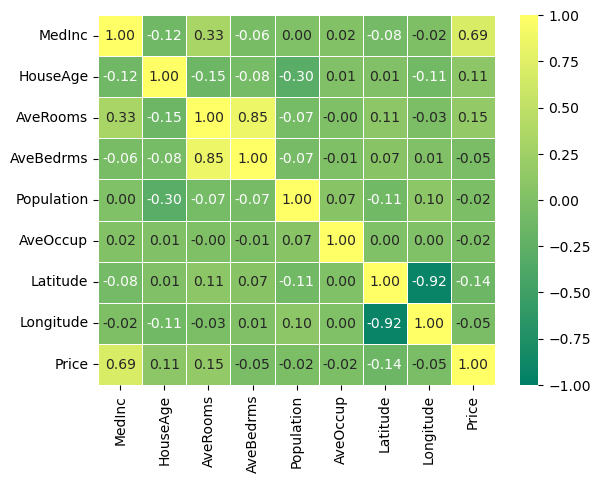

In [147]:
corr = df.corr()

sns.heatmap(corr, annot = True, fmt='.2f', cmap='summer',
            linewidths=0.5, vmin=-1, vmax=1)

In [148]:
df.skew()

MedInc         1.646657
HouseAge       0.060331
AveRooms      20.697869
AveBedrms     31.316956
Population     4.935858
AveOccup      97.639561
Latitude       0.465953
Longitude     -0.297801
Price          0.977763
dtype: float64

Text(0.5, 1.0, 'QQ Plot of Price')

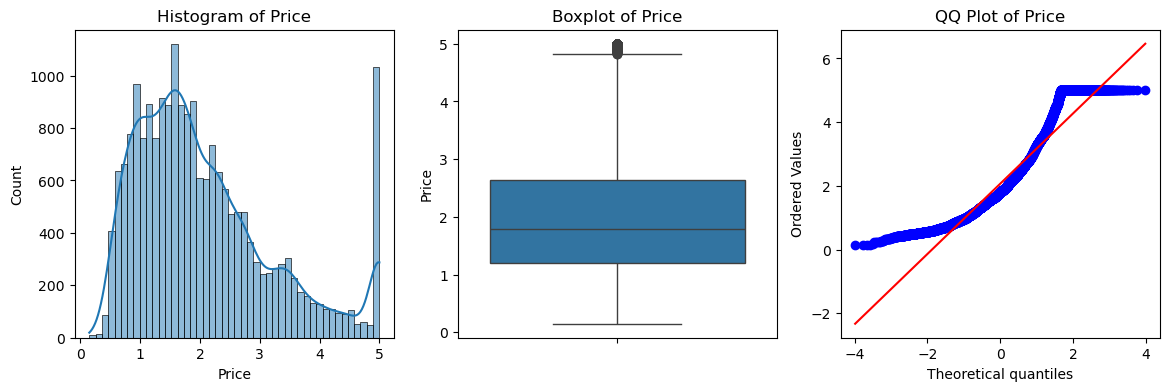

In [149]:
plt.figure(figsize=(14,4))
plt.subplot(131)
sns.histplot(df['Price'],kde=True)
plt.title(f'Histogram of Price')

plt.subplot(132)
sns.boxplot(df['Price'])
plt.title(f'Boxplot of Price')

plt.subplot(133)
stats.probplot(df['Price'], dist='norm', plot=plt)
plt.title(f'QQ Plot of Price')

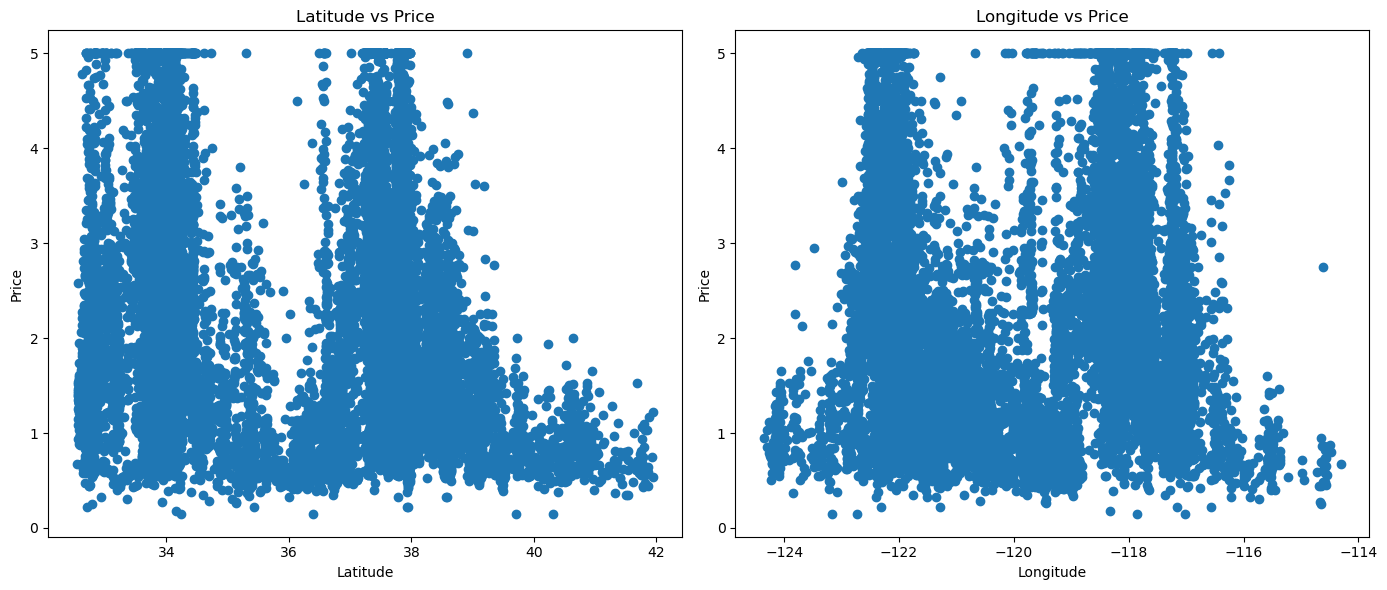

In [150]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.scatter(df['Latitude'], df['Price'])
plt.xlabel("Latitude")
plt.ylabel("Price")
plt.title("Latitude vs Price")

plt.subplot(1,2,2)
plt.scatter(df['Longitude'], df['Price'])
plt.xlabel("Longitude")
plt.ylabel("Price")
plt.title("Longitude vs Price")

plt.tight_layout()
plt.show()

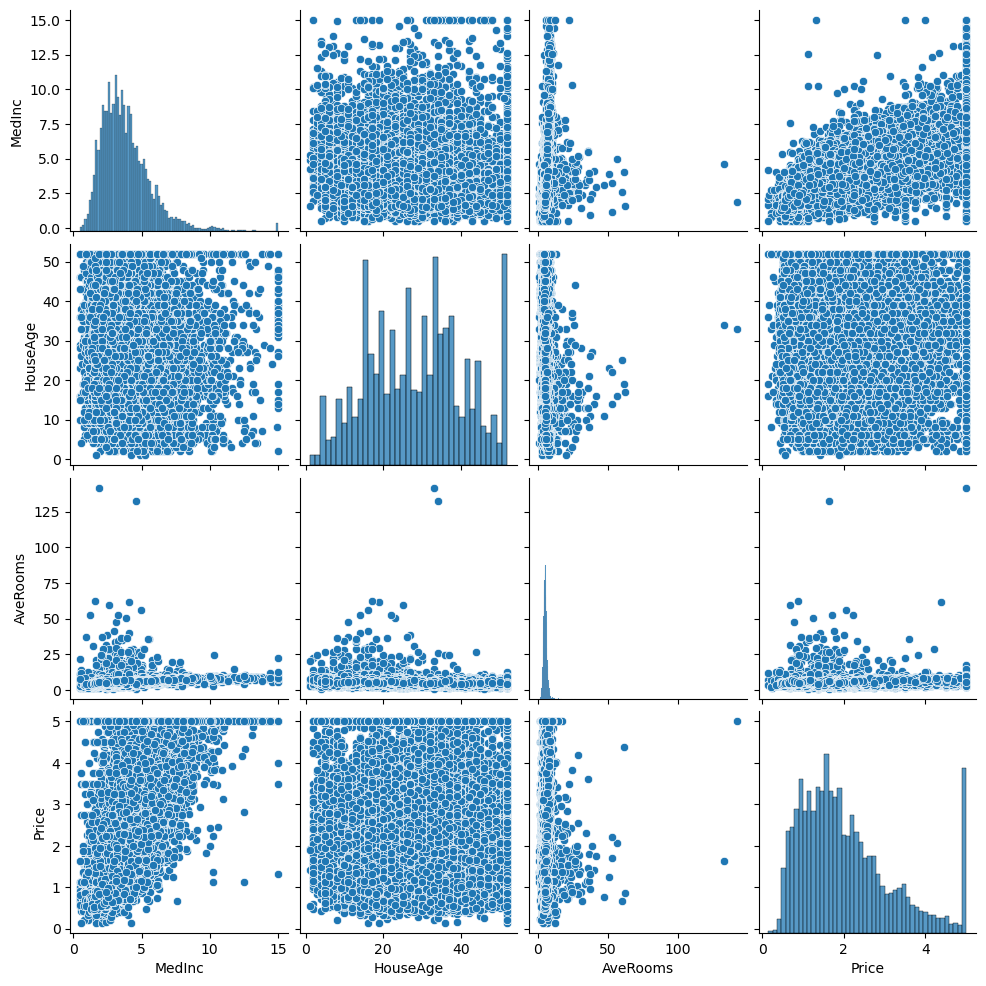

In [151]:
sns.pairplot(df[['MedInc','HouseAge','AveRooms','Price']])

In [152]:
X = df.drop(['Price'], axis=1)
y = np.log1p(df['Price'])

In [153]:
print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [154]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [155]:
skewed_cols = ['Population', 'AveOccup', 'AveRooms', 'AveBedrms']
normal_cols = ['MedInc', 'HouseAge','Latitude', 'Longitude']

preprocessor = ColumnTransformer([
    ('power_robust', Pipeline([
        ('pt', PowerTransformer(method='yeo-johnson')),
        ('sc', RobustScaler())
    ]), skewed_cols),
    ('robust', RobustScaler(), normal_cols)
], remainder='passthrough')


In [156]:
models = {
    'Ridge':          Ridge(alpha=1.0),
    'Lasso':          Lasso(alpha=0.001, max_iter=5000),
    'Random Forest':  RandomForestRegressor(
                          n_estimators=200, max_depth=16,
                          min_samples_leaf=2, n_jobs=-1,random_state=42),
    'Gradient Boost': GradientBoostingRegressor(
                          n_estimators=300, learning_rate=0.05,
                          max_depth=5, subsample=0.8,random_state=42),
}

cv = KFold(n_splits=5, shuffle=True,random_state=42)
results = []
pipes   = {}

for name, mdl in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', mdl)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)
    pipe.fit(X_train, y_train)

    yp_log = pipe.predict(X_test)
    yp     = np.expm1(yp_log)
    yt     = np.expm1(y_test)

    results.append({
        'Model':    name,
        'CV R²':    cv_scores.mean(),
        'CV ± std': cv_scores.std(),
        'Test R²':  r2_score(y_test, yp_log),
        'RMSE':     root_mean_squared_error(yt, yp),
        'MAE':      mean_absolute_error(yt, yp),
    })
    pipes[name] = pipe
    print(f'{name:20s} | CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} Test R²: {r2_score(y_test, yp_log)}' )


Ridge                | CV R²: 0.6838 ± 0.0076 Test R²: 0.6709041178617952
Lasso                | CV R²: 0.6830 ± 0.0074 Test R²: 0.6699612128421808
Random Forest        | CV R²: 0.8237 ± 0.0053 Test R²: 0.8232176072014071
Gradient Boost       | CV R²: 0.8430 ± 0.0046 Test R²: 0.8391982657890815


In [157]:
results_df = pd.DataFrame(results).sort_values('CV R²', ascending=False)
results_df

,Model,CV R²,CV ± std,Test R²,RMSE,MAE
3,Gradient Boost,0.842971,0.004567,0.839198,0.479171,0.311919
2,Random Forest,0.823704,0.005269,0.823218,0.512465,0.322701
0,Ridge,0.683832,0.007618,0.670904,0.733727,0.481382
1,Lasso,0.683049,0.007406,0.669961,0.736884,0.484393


In [158]:
best_name = results_df.iloc[0]['Model']
best_pipe = pipes[best_name]
print(f'Best model: {best_name}')

Best model: Gradient Boost


In [159]:
yp_log_best = best_pipe.predict(X_test)
yp_best     = np.expm1(yp_log_best)
yt_orig     = np.expm1(y_test)

In [160]:
r2   = r2_score(y_test, yp_log_best)
rmse = root_mean_squared_error(yt_orig, yp_best)
mae  = mean_absolute_error(yt_orig, yp_best)

In [161]:
print(f'R² : {r2:.4f}')
# Convert from 100,000-dollar units to dollars
print(f'RMSE : ${rmse*100_000:,.0f}')
print(f'MAE : ${mae*100_000:,.0f}')

R² : 0.8392
RMSE : $47,917
MAE : $31,192


In [162]:
import joblib

joblib.dump(best_pipe, 'house_model.pkl')
print('Model saved → house_price_model.pkl')

Model saved → house_price_model.pkl
